# PolEval 2021 – Zadanie 4: Question Answering

Celem zadania jest automatyczne odpowiadanie na pytania ogólnowiedzy w stylu teleturnieju **Jeden z dziesięciu**.

## Podejście — BM25 + Extractive QA (bez zewnętrznych API)

Budujemy lokalny system RAG oparty wyłącznie na offline'owych zasobach:

1. **Indeks BM25** zbudowany z lokalnego zrzutu polskiej Wikipedii (`wiki_articles.jsonl`)
2. **Retrieval** — dla pytania wyszukujemy najbardziej trafne fragmenty artykułów
3. **Extractive answer selection** — z pobranych fragmentów heurystycznie wyciągamy kandydatów na odpowiedź
4. **Ewaluacja** — dokładnie wg metryki PolEval (odległość Levenshteina / porównanie numeryczne)

System działa w pełni offline — nie korzysta z żadnego zewnętrznego API ani wyszukiwarki podczas inferowania.

## 1. Instalacja zależności

In [2]:
import sys
!{sys.executable} -m pip install rank_bm25 python-Levenshtein tqdm --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## 2. Importy i konfiguracja

In [21]:
import json
import re
import pickle
import os
import time
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
from tqdm import tqdm
from rank_bm25 import BM25Okapi
import Levenshtein

# ── Konfiguracja ──────────────────────────────────────────────────────────
WIKI_PATH    = "wiki_articles.jsonl"   # lokalny zrzut Wikipedii (~4 GB)
DATA_DIR     = "poleval_data"          # katalog z danymi konkursu
INDEX_PATH   = "bm25_index.pkl"        # plik cache indeksu BM25
CORPUS_PATH  = "corpus_chunks.pkl"     # plik cache fragmentów tekstu

TOP_K        = 5     # liczba fragmentów do retrieval
CHUNK_SIZE   = 150   # maks. liczba słów na fragment (mniejsze = precyzyjniejsze)
MAX_ARTICLES = None  # None = cały zrzut; int np. 50_000 = szybki test

print("Konfiguracja załadowana ✓")
print(f"  WIKI_PATH  : {WIKI_PATH}")
print(f"  TOP_K      : {TOP_K}")
print(f"  CHUNK_SIZE : {CHUNK_SIZE} słów")

Konfiguracja załadowana ✓
  WIKI_PATH  : wiki_articles.jsonl
  TOP_K      : 5
  CHUNK_SIZE : 150 słów


## 3. Wczytanie danych konkursowych

In [22]:
import subprocess
if not Path("poleval_data").exists():
    subprocess.run(["git", "clone", 
                    "https://github.com/poleval/2021-question-answering.git",
                    "poleval_data"], check=True)
    print("Dane pobrane ✓")
else:
    print("Dane już istnieją ✓")

Dane już istnieją ✓


In [23]:
def load_tsv_lines(path: str) -> List[str]:
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def load_answers(path: str) -> List[List[str]]:
    """Każda linia może zawierać kilka wariantów oddzielonych tabulatorem."""
    answers = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            variants = [v.strip() for v in line.strip().split("\t") if v.strip()]
            answers.append(variants)
    return answers

dev_questions  = load_tsv_lines(f"{DATA_DIR}/dev-0/in.tsv")
dev_answers    = load_answers(f"{DATA_DIR}/dev-0/expected.tsv")
test_questions = load_tsv_lines(f"{DATA_DIR}/test-A/in.tsv")

print(f"Dev-0  : {len(dev_questions)} pytań")
print(f"Test-A : {len(test_questions)} pytań")
print()
print("Przykłady z dev-0:")
for i in range(5):
    print(f"  Q: {dev_questions[i]}")
    print(f"  A: {dev_answers[i]}")
    print()

Dev-0  : 1000 pytań
Test-A : 2500 pytań

Przykłady z dev-0:
  Q: Jak nazywa się pierwsza litera alfabetu greckiego?
  A: ['alfa']

  Q: Jak nazywa się dowolny odcinek łączący dwa punkty okręgu?
  A: ['cięciwa']

  Q: W którym państwie rozpoczyna się akcja powieści „W pustyni i w puszczy”?
  A: ['w Egipcie']

  Q: Czy w państwach starożytnych powoływani byli posłowie i poselstwa?
  A: ['tak']

  Q: W jakim zespole występowała Hanka w filmie „Żona dla Australijczyka”?
  A: ['Mazowsze']



## 4. Tokenizacja

Używamy prostej tokenizacji regeksowej dla języka polskiego — bez modelu spaCy,  
żeby uniknąć zależności sieciowych. Podejście spójne z baseline PolEval  
(który tokenizuje spaCy i odrzuca tokeny jednoznakowe).  

Ignorujemy tokeny jednoznakowe (identycznie jak baseline).

In [24]:
# Polskie znaki diakrytyczne uwzględnione wprost w wyrażeniu regularnym
PL_CHARS = "ąćęłńóśźżĄĆĘŁŃÓŚŹŻ"

def tokenize_pl(text: str) -> List[str]:
    """
    Tokenizacja dla języka polskiego.
    Wyodrębnia ciągi liter i cyfr, zamienia na małe litery,
    odrzuca tokeny jednoznakowe (jak w baseline PolEval).
    """
    pattern = rf"[a-z{PL_CHARS}A-Z0-9]+"
    tokens = re.findall(pattern, text.lower())
    return [t for t in tokens if len(t) > 1]


# Test tokenizatora
examples = [
    "Jak nazywa się pierwsza litera alfabetu greckiego?",
    "W którym państwie leży Bombaj?",
    "Ile pełnych tygodni ma rok kalendarzowy?",
]
for ex in examples:
    print(f"  IN : {ex}")
    print(f"  OUT: {tokenize_pl(ex)}")
    print()

  IN : Jak nazywa się pierwsza litera alfabetu greckiego?
  OUT: ['jak', 'nazywa', 'się', 'pierwsza', 'litera', 'alfabetu', 'greckiego']

  IN : W którym państwie leży Bombaj?
  OUT: ['którym', 'państwie', 'leży', 'bombaj']

  IN : Ile pełnych tygodni ma rok kalendarzowy?
  OUT: ['ile', 'pełnych', 'tygodni', 'ma', 'rok', 'kalendarzowy']



## 5. Budowa indeksu BM25

**BM25 (Best Match 25)** to klasyczny probabilistyczny model wyszukiwania informacji —  
rozwinięcie TF-IDF z normalizacją długości dokumentu i nasyceniem częstości.  
Jest to standardowe narzędzie w systemach IR i QA sprzed ery LLM-ów.

### Strategia chunkingu
Dzielimy każdy artykuł na fragmenty po `CHUNK_SIZE` słów:
- Mniejsze fragmenty → bardziej precyzyjne dopasowanie (mniej szumu)
- Każdy fragment zaczyna się od tytułu artykułu → BM25 może matchować po tytule

### Cache
Indeks budujemy raz i zapisujemy do pliku `.pkl` — przebudowanie dla pełnej  
Wikipedii (~4 GB) zajmuje kilkanaście minut i ~8 GB RAM.

In [ ]:
from pathlib import Path
import sqlite3
from typing import List

DB_PATH = "wiki_index.db" 

def chunk_text(title: str, text: str, max_chars: int = 1000) -> List[str]:
    """
    Dzieli tekst artykułu na mniejsze fragmenty (akapity), 
    łącząc zbyt krótkie linie w optymalne chunki.
    """
    # Dzielimy tekst na akapity na podstawie znaków nowej linii
    paragraphs = text.split("\n")
    chunks = []
    current_chunk = []
    current_length = 0

    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        # Jeśli dodanie kolejnego akapitu przekroczy limit znaków,
        # zapisujemy dotychczasowy chunk i zaczynamy nowy
        if current_length + len(para) > max_chars and current_chunk:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            current_length = 0

        current_chunk.append(para)
        current_length += len(para)

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    # Jeśli artykuł był bardzo krótki i nie wygenerował żadnego chunka,
    # zwracamy chociaż sam tekst (lub tytuł), żeby nie zgubić danych
    if not chunks and text.strip():
        chunks.append(text.strip())

    return chunks

def build_sqlite_index(
    wiki_path: str,
    db_path: str = DB_PATH,
    max_articles: Optional[int] = None,
):
    """
    Buduje dyskowy indeks wyszukiwania SQLite FTS5.
    Zużywa minimalną ilość RAM-u, zapisując dane partiami na dysk.
    """
    if Path(db_path).exists():
        print(f"Indeks SQLite już istnieje w {db_path} ✓ (Wczytywanie pominięte - baza jest na dysku)")
        return

    print("Budowanie dyskowego indeksu SQLite FTS5...")
    print("(Bezpieczne dla RAM-u — przetwarza cały zrzut 4 GB)")

    # Połączenie z bazą danych na dysku
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Tworzymy wirtualną tabelę Full-Text Search (FTS5) z algorytmem BM25
    cursor.execute("""
        CREATE VIRTUAL TABLE IF NOT EXISTS wiki_chunks USING fts5(
            title,
            raw_chunk,
            tokenized_chunk,
            tokenize="unicode61"
        );
    """)

    n_articles = 0
    batch = []
    BATCH_SIZE = 2000  

    with open(wiki_path, encoding="utf-8") as f:
        for line in tqdm(f, desc="Artykuły", unit=" art."):
            line = line.strip()
            if not line:
                continue
            try:
                article = json.loads(line)
            except json.JSONDecodeError:
                continue

            title = article.get("title", "").strip()
            text  = article.get("text",  "").strip()
            if not title or not text:
                continue

            # Przetwarzamy tekst artykułu na chunki
            for chunk in chunk_text(title, text):
                tokens = tokenize_pl(chunk)
                tokenized_str = " ".join(tokens)
                
                # Zapisujemy do paczki: tytuł, oryginalny fragment, oraz wersję przetworzoną dla BM25
                batch.append((title, chunk, tokenized_str))

                # Jeśli uzbieraliśmy paczkę, zrzucamy ją na dysk i czyścimy RAM
                if len(batch) >= BATCH_SIZE:
                    cursor.executemany(
                        "INSERT INTO wiki_chunks (title, raw_chunk, tokenized_chunk) VALUES (?, ?, ?)", 
                        batch
                    )
                    conn.commit()
                    batch = []

            n_articles += 1
            if max_articles and n_articles >= max_articles:
                break

    # Zapisujemy resztę danych, która została w ostatniej paczce
    if batch:
        cursor.executemany(
            "INSERT INTO wiki_chunks (title, raw_chunk, tokenized_chunk) VALUES (?, ?, ?)", 
            batch
        )
        conn.commit()

    print(f"Sukces! Indeks gotowy na dysku. Przetworzono artykułów: {n_articles:,}")
    conn.close()


# Uruchomienie dla CAŁEGO zbioru danych (max_articles=None)
build_sqlite_index(WIKI_PATH, max_articles=None)

Budowanie dyskowego indeksu SQLite FTS5...
(Bezpieczne dla RAM-u — przetwarza cały zrzut 4 GB)


Artykuły: 2791756 art. [10:20, 4497.39 art./s] 

Sukces! Indeks gotowy na dysku. Przetworzono artykułów: 2,791,756


## 6. Retrieval — wyszukiwanie trafnych fragmentów

In [ ]:
def retrieve(
    question: str,
    db_path: str = DB_PATH,
    top_k: int = TOP_K,
) -> List[str]:
    query_tokens = tokenize_pl(question)
    if not query_tokens:
        return []

    STOP_WORDS = {"w", "z", "na", "o", "do", "i", "a", "ze", "za", "po", "czy", "jak", "sie", "siebie", "ktory", "ktora", "wtedy", "jest", "sa", "bylo"}
    important_tokens = [t for t in query_tokens if t not in STOP_WORDS]
    
    if not important_tokens:
        important_tokens = query_tokens

    sqlite_query = " OR ".join(important_tokens)

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT title, raw_chunk FROM wiki_chunks 
        WHERE tokenized_chunk MATCH ? 
        ORDER BY bm25(wiki_chunks) 
        LIMIT ?
    """, (sqlite_query, top_k))

    # Składamy je w format oczekiwany przez resztę pipeline'u ("Tytuł: Treść")
    results = [f"{row[0]}: {row[1]}" for row in cursor.fetchall()]
    conn.close()
    return results

## 7. Extractive Answer Selection

Zamiast generować odpowiedź modelem językowym, **wyciągamy ją z tekstu** — podejście  
typowe dla systemów QA z lat 2018–2021 (np. DrQA, BERT-based reader).

Zastosowane heurystyki (bez modelu ML):
1. **Tak/Nie** — jeśli pytanie zaczyna się od "Czy", szukamy "tak"/"nie" w fragmentach
2. **Liczba** — pytania "Ile/Ilu/W którym roku" → wyciągamy pierwszą liczbę z kontekstu
3. **Zdanie z pytajnikiem** — szukamy zdania/frazy zawierającej tokeny z pytania
4. **Tytuł artykułu** — fallback: tytuł pierwszego dopasowanego artykułu (jak baseline)

In [ ]:
import re
from typing import List, Dict, Optional

def is_yesno_question(q: str) -> bool:
    return q.lower().strip().startswith("czy")


def is_numeric_question(q: str) -> bool:
    kws = ["ile ", "ilu ", "który rok", "w którym roku", "w jakim roku",
           "jaki rok", "ile lat", "ile dni", "ile razy", "o ile"]
    ql = q.lower()
    return any(ql.startswith(kw) or kw in ql for kw in kws)


def extract_yesno(chunks: List[str]) -> str:
    tak, nie = 0, 0
    for chunk in chunks:
        cl = chunk.lower()
        tak += cl.count(" tak ") + cl.count("\ntak") + cl.count("jest tak")
        nie += cl.count(" nie ") + cl.count("\nnie") + cl.count("jest nie")
    return "tak" if tak >= nie else "nie"


def extract_number(chunks: List[str], question: str) -> str:
    """Wyciąga pierwszą liczbę pasującą do kontekstu pytania (mądrze omija lata)."""
    q_tokens = set(tokenize_pl(question))
    is_count_query = any(kw in question.lower() for kw in ["ile", "ilu"])

    for chunk in chunks:
        sentences = re.split(r'[.!?;]', chunk)
        for sent in sentences:
            sent_tokens = set(tokenize_pl(sent))
            if len(q_tokens & sent_tokens) >= 2:
                nums = re.findall(r'\b\d+\b', sent)
                if nums:
                    if is_count_query:
                        filtered = [n for n in nums if not (len(n) == 4 and 1000 <= int(n) <= 2030)]
                        if filtered: return filtered[0]
                    return nums[0]

    # Fallback
    for chunk in chunks:
        nums = re.findall(r'\b\d+\b', chunk)
        if nums:
            if is_count_query:
                filtered = [n for n in nums if not (len(n) == 4 and 1000 <= int(n) <= 2030)]
                if filtered: return filtered[0]
            return nums[0]
    return ""


def extract_from_context(question: str, chunks: List[str]) -> str:
    q_tokens = set(tokenize_pl(question))
    answer_triggers = [
        "to ", "jest ", "był ", "była ", "byli ", "są ", "nazywa się ",
        "nazywał się ", "nosi nazwę ", "to jest ", "znany jako ",
        "zwany ", "określany ", "stanowi ", "oznacza "
    ]
    best_phrase = ""
    best_score  = -1

    for chunk in chunks:
        sentences = re.split(r'(?<=[.!?;])\s+', chunk)
        for sent in sentences:
            s_tokens = set(tokenize_pl(sent))
            overlap  = len(q_tokens & s_tokens)
            if overlap < 2:
                continue

            for trigger in answer_triggers:
                idx = sent.lower().find(trigger)
                if idx != -1:
                    candidate = sent[idx + len(trigger):].strip()
                    candidate = re.split(r'[,;(\[]', candidate)[0].strip()
                    candidate_words = candidate.split()[:6]
                    candidate = " ".join(candidate_words)
                    if candidate and overlap > best_score:
                        best_score  = overlap
                        best_phrase = candidate
    return best_phrase


def get_article_title(chunk: str) -> str:
    """Wyciąga prawdziwy tytuł artykułu."""
    match = re.match(r'^(.+?):', chunk)
    if match:
        title = match.group(1).strip()
        title = re.sub(r'\s*\(.*', '', title).strip()
        return title
    return chunk.split()[0]


def answer_question(question: str, chunks: List[str]) -> str:
    if not chunks:
        return ""
    if is_yesno_question(question):
        return extract_yesno(chunks)
    if is_numeric_question(question):
        num = extract_number(chunks, question)
        if num: return num
    phrase = extract_from_context(question, chunks)
    if phrase: return phrase

    return get_article_title(chunks[0])


# ── Ponowne Demo ──────────────────────────────────────────────────────────
demo_qs = [
    ("Jak nazywa się pierwsza litera alfabetu greckiego?", ["alfa"]),
    ("Czy owoce niektórych kaktusów są jadalne?",          ["tak"]),
    ("Kwartet – to ilu wykonawców?",                       ["czterech", "czworo", "4"]),
    ("W którym państwie leży Bombaj?",                     ["w Indiach"]),
]
print("Demo extractive QA (Po poprawkach formatowania):")
print("-" * 60)
for q, gold in demo_qs:
    chunks = retrieve(q, db_path=DB_PATH) 
    pred   = answer_question(q, chunks)
    ok = "✓" if any(
        Levenshtein.distance(pred.lower(), g.lower()) <= len(g)/2 for g in gold
    ) else "✗"
    print(f"{ok} Q: {q}")
    print(f"   Gold: {gold}  |  Pred: {pred}")
    print()

Demo extractive QA (Po poprawkach formatowania):
------------------------------------------------------------
✗ Q: Jak nazywa się pierwsza litera alfabetu greckiego?
   Gold: ['alfa']  |  Pred: zakodowana:

✓ Q: Czy owoce niektórych kaktusów są jadalne?
   Gold: ['tak']  |  Pred: tak

✗ Q: Kwartet – to ilu wykonawców?
   Gold: ['czterech', 'czworo', '4']  |  Pred: 1965

✗ Q: W którym państwie leży Bombaj?
   Gold: ['w Indiach']  |  Pred: Port lotniczy Goa



## 8. Metryka ewaluacji (zgodna z PolEval 2021)

Zgodnie ze specyfikacją konkursu:
- **Pytania nienumeryczne**: odległość Levenshteina(pred, gold) < ½ len(gold)
- **Pytania numeryczne**: ekstrakcja liczby i porównanie wartości
- Jeśli jest wiele wariantów złotej odpowiedzi — wystarczy dopasować jeden

In [28]:
def answers_match(prediction: str, gold_variants: List[str], question: str = "") -> bool:
    """
    Sprawdza dopasowanie zgodnie ze specyfikacją PolEval 2021.

    Args:
        prediction:    odpowiedź systemu
        gold_variants: lista wariantów złotej odpowiedzi
        question:      treść pytania (używana do wykrycia pytań numerycznych)

    Returns:
        True jeśli przynajmniej jeden wariant pasuje.
    """
    pred = prediction.lower().strip()

    for gold in gold_variants:
        gold_clean = gold.lower().strip()

        if is_numeric_question(question):
            # Porównanie numeryczne
            pm = re.search(r'\d+', pred)
            gm = re.search(r'\d+', gold_clean)
            if pm and gm and pm.group() == gm.group():
                return True
        else:
            # Porównanie przez odległość Levenshteina
            dist = Levenshtein.distance(pred, gold_clean)
            if len(gold_clean) > 0 and dist < len(gold_clean) / 2:
                return True

    return False


def evaluate(questions, gold_answers, predictions) -> Dict:
    """Oblicza accuracy na liście pytań."""
    assert len(questions) == len(gold_answers) == len(predictions)
    n_correct = sum(
        answers_match(p, g, q)
        for p, g, q in zip(predictions, gold_answers, questions)
    )
    n_total = len(questions)
    return {
        "accuracy":  n_correct / n_total,
        "n_correct": n_correct,
        "n_total":   n_total,
    }


# Szybki test metryki
print("Test metryki ewaluacji:")
cases = [
    ("alfa",          ["alfa"],         "",           True),
    ("alpha",         ["alfa"],         "",           False),   # dist=2, len=4, 2 < 2? → False
    ("52",            ["52"],           "Ile tygodni",True),
    ("czterech",      ["czterech","4"], "",           True),
    ("Orwell",        ["George Orwell"],"",           False),  # dist=7, len=13, 7 < 6.5? → False
    ("tak",           ["tak"],          "Czy...",     True),
]
for pred, gold, q, expected in cases:
    result = answers_match(pred, gold, q)
    status = "✓" if result == expected else "✗ BŁĄD"
    print(f"  {status}  '{pred}' vs {gold}  → {result}")

Test metryki ewaluacji:
  ✓  'alfa' vs ['alfa']  → True
  ✓  'alpha' vs ['alfa']  → False
  ✓  '52' vs ['52']  → True
  ✓  'czterech' vs ['czterech', '4']  → True
  ✓  'Orwell' vs ['George Orwell']  → False
  ✓  'tak' vs ['tak']  → True


## 9. Pełny pipeline — zbiór deweloperski

In [ ]:
def run_pipeline(
    questions: List[str],
    db_path: str = DB_PATH,                
    top_k: int = TOP_K,
    save_path: Optional[str] = None,
) -> List[str]:
    """
    Uruchamia pełny pipeline dla listy pytań przy użyciu bazy SQLite.

    Steps: tokenize question → SQLite FTS5 BM25 retrieval → extractive answer selection
    """
    predictions = []
    for question in tqdm(questions, desc="Odpowiadanie", unit=" pyt."):
        chunks = retrieve(question, db_path=db_path, top_k=top_k)
        answer = answer_question(question, chunks)
        predictions.append(answer)

    if save_path:
        Path(save_path).write_text("\n".join(predictions) + "\n", encoding="utf-8")
        print(f"Odpowiedzi zapisane: {save_path}")

    return predictions


# Uruchomienie na dev-0
print("Uruchamianie pipeline na zbiorze deweloperskim (1000 pytań)...")
dev_predictions = run_pipeline(dev_questions, db_path=DB_PATH, save_path="dev_predictions.tsv")

results = evaluate(dev_questions, dev_answers, dev_predictions)
print()
print("=" * 45)
print("WYNIKI — dev-0")
print("=" * 45)
print(f"Accuracy  : {results['accuracy']:.4f}  ({results['accuracy']*100:.2f}%)")
print(f"Poprawne  : {results['n_correct']} / {results['n_total']}")

Uruchamianie pipeline na zbiorze deweloperskim (1000 pytań)...


Odpowiadanie: 100%|██████████| 1000/1000 [28:29<00:00,  1.71s/ pyt.]

Odpowiedzi zapisane: dev_predictions.tsv

WYNIKI — dev-0
Accuracy  : 0.0560  (5.60%)
Poprawne  : 56 / 1000


## 10. Analiza błędów

In [30]:
def show_errors(questions, gold_answers, predictions, n=25):
    """Wyświetla błędnie odpowiedziane pytania — pomaga zrozumieć słabości systemu."""
    errors = [
        (q, g, p)
        for q, g, p in zip(questions, gold_answers, predictions)
        if not answers_match(p, g, q)
    ]
    print(f"Błędy: {len(errors)} / {len(questions)}")
    print(f"Accuracy: {(len(questions)-len(errors))/len(questions)*100:.2f}%\n")
    for i, (q, g, p) in enumerate(errors[:n], 1):
        print(f"[{i:3d}] Q: {q}")
        print(f"       Gold: {g}")
        print(f"       Pred: {p}")
        print()

show_errors(dev_questions, dev_answers, dev_predictions)

Błędy: 944 / 1000
Accuracy: 5.60%

[  1] Q: Jak nazywa się pierwsza litera alfabetu greckiego?
       Gold: ['alfa']
       Pred: zakodowana:

[  2] Q: Jak nazywa się dowolny odcinek łączący dwa punkty okręgu?
       Gold: ['cięciwa']
       Pred: odcinek wyznaczony przez punkty wspólne dowolnej

[  3] Q: W którym państwie rozpoczyna się akcja powieści „W pustyni i w puszczy”?
       Gold: ['w Egipcie']
       Pred: dużym fanem powieści Sienkiewicza

[  4] Q: Czy w państwach starożytnych powoływani byli posłowie i poselstwa?
       Gold: ['tak']
       Pred: nie

[  5] Q: W jakim zespole występowała Hanka w filmie „Żona dla Australijczyka”?
       Gold: ['Mazowsze']
       Pred: Elżbieta Czyżewska

[  6] Q: W którym państwie leży Bombaj?
       Gold: ['w Indiach']
       Pred: Port lotniczy Goa

[  7] Q: Który numer boczny nosi czołg Rudy z „Czterech pancernych”?
       Gold: ['102']
       Pred: liczbą atomową pierwiastka nobla droga wojewódzka

[  8] Q: Co budował w Egipcie inżynier 

## 11. Analiza accuracy per typ pytania

In [32]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 16.2 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 2.7 MB/s  eta 0:00:01
     |████████████████████████████████| 2.9 MB 46.5 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 27.8 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 5.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


Kategoria            N     OK   Accuracy
------------------------------------------
Inne               294      3       1.0%
Jak/Jaki           292      7       2.4%
Kto/Który          128      1       0.8%
Gdzie              124      2       1.6%
Tak/Nie            100     41      41.0%
Co                  31      1       3.2%
Numeryczne          31      1       3.2%


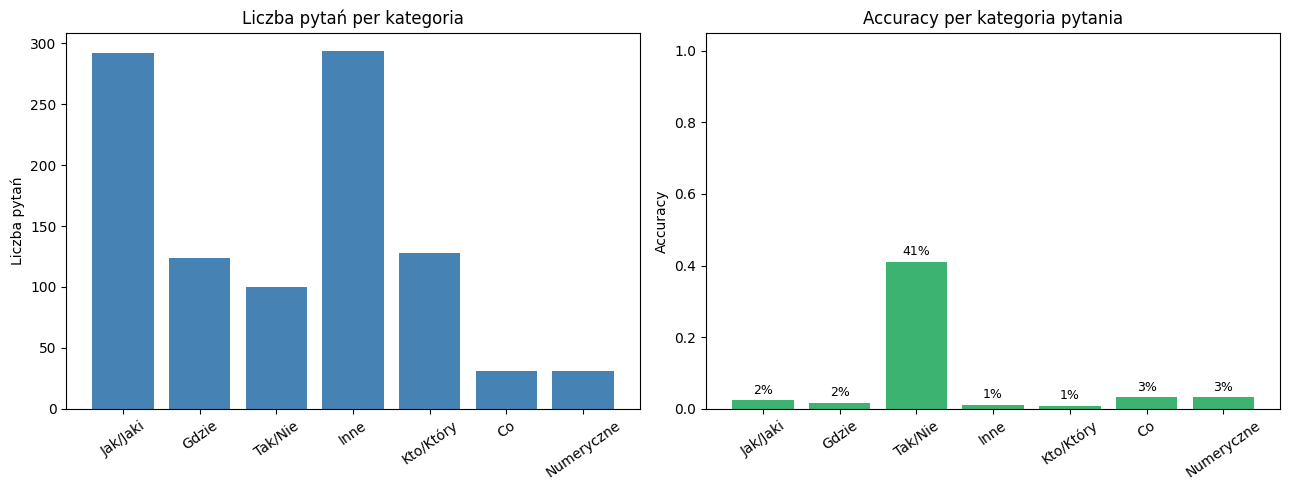

Wykres zapisany: accuracy_per_category.png


In [33]:
import matplotlib.pyplot as plt

def categorize(q: str) -> str:
    ql = q.lower()
    if ql.startswith("czy"):
        return "Tak/Nie"
    if any(ql.startswith(w) for w in ["ile ", "ilu "]):
        return "Numeryczne"
    if any(ql.startswith(w) for w in ["kto ", "który ", "która ", "które "]):
        return "Kto/Który"
    if any(ql.startswith(w) for w in ["co ", "czym ", "czego "]):
        return "Co"
    if any(ql.startswith(w) for w in ["gdzie ", "w któr"]):
        return "Gdzie"
    if any(ql.startswith(w) for w in ["jak ", "jaki ", "jaka ", "jakie "]):
        return "Jak/Jaki"
    if any(ql.startswith(w) for w in ["kiedy ", "w którym roku"]):
        return "Kiedy"
    return "Inne"

# Zlicz wyniki per kategoria
stats = {}
for q, g, p in zip(dev_questions, dev_answers, dev_predictions):
    cat = categorize(q)
    if cat not in stats:
        stats[cat] = {"ok": 0, "n": 0}
    stats[cat]["n"] += 1
    if answers_match(p, g, q):
        stats[cat]["ok"] += 1

print(f"{'Kategoria':<15} {'N':>6} {'OK':>6} {'Accuracy':>10}")
print("-" * 42)
for cat, s in sorted(stats.items(), key=lambda x: -x[1]["n"]):
    acc = s["ok"] / s["n"]
    print(f"{cat:<15} {s['n']:>6} {s['ok']:>6} {acc:>10.1%}")

# Wykres
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
cats = list(stats.keys())
ns   = [stats[c]["n"]           for c in cats]
accs = [stats[c]["ok"]/stats[c]["n"] for c in cats]

ax1.bar(cats, ns, color="steelblue")
ax1.set_title("Liczba pytań per kategoria")
ax1.set_ylabel("Liczba pytań")
ax1.tick_params(axis="x", rotation=35)

bars = ax2.bar(cats, accs, color="mediumseagreen")
ax2.set_title("Accuracy per kategoria pytania")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="x", rotation=35)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.0%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("accuracy_per_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany: accuracy_per_category.png")

## 12. Ablacja — wpływ parametrów na accuracy

Badamy wpływ `top_k` (liczba fragmentów) na wyniki.  
Większe `top_k` = więcej kontekstu, ale więcej szumu.

Odpowiadanie: 100%|██████████| 200/200 [06:01<00:00,  1.81s/ pyt.]


top_k= 1  accuracy=0.0900  (9.0%)


Odpowiadanie: 100%|██████████| 200/200 [05:41<00:00,  1.71s/ pyt.]


top_k= 3  accuracy=0.0800  (8.0%)


Odpowiadanie: 100%|██████████| 200/200 [05:42<00:00,  1.71s/ pyt.]


top_k= 5  accuracy=0.0650  (6.5%)


Odpowiadanie: 100%|██████████| 200/200 [05:22<00:00,  1.61s/ pyt.]

top_k=10  accuracy=0.0450  (4.5%)


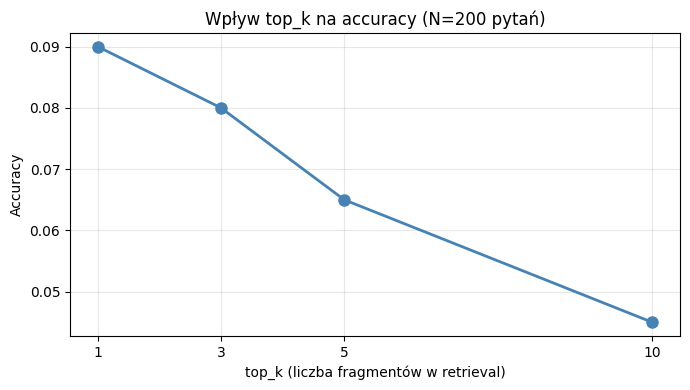

In [34]:
ABLATION_N = 200   
ablation_q = dev_questions[:ABLATION_N]
ablation_a = dev_answers[:ABLATION_N]

results_ablation = {}
for k in [1, 3, 5, 10]:
    preds = run_pipeline(ablation_q, db_path=DB_PATH, top_k=k)
    res   = evaluate(ablation_q, ablation_a, preds)
    results_ablation[k] = res["accuracy"]
    print(f"top_k={k:2d}  accuracy={res['accuracy']:.4f}  ({res['accuracy']*100:.1f}%)")

plt.figure(figsize=(7, 4))
plt.plot(list(results_ablation.keys()), list(results_ablation.values()),
         marker="o", color="steelblue", linewidth=2, markersize=8)
plt.xlabel("top_k (liczba fragmentów w retrieval)")
plt.ylabel("Accuracy")
plt.title(f"Wpływ top_k na accuracy (N={ABLATION_N} pytań)")
plt.xticks(list(results_ablation.keys()))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_topk.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Generowanie odpowiedzi dla zbioru testowego A

In [35]:
print("Generowanie odpowiedzi dla test-A (2500 pytań)...")
test_predictions = run_pipeline(test_questions, db_path=DB_PATH, save_path="test_A_out.tsv")

print(f"\nWygenerowano {len(test_predictions)} odpowiedzi")
print("\nPierwsze 10 odpowiedzi:")
for q, a in zip(test_questions[:10], test_predictions[:10]):
    print(f"  Q: {q}")
    print(f"  A: {a}")
    print()

Generowanie odpowiedzi dla test-A (2500 pytań)...


Odpowiadanie: 100%|██████████| 2500/2500 [1:11:49<00:00,  1.72s/ pyt.]

Odpowiedzi zapisane: test_A_out.tsv

Wygenerowano 2500 odpowiedzi

Pierwsze 10 odpowiedzi:
  Q: Czy poeta Lucjan Rydel tworzył także sztuki teatralne?
  A: tak

  Q: W którym państwie została ogłoszona „Deklaracja praw człowieka i obywatela”?
  A: burżuazja

  Q: Która kawa zawiera alkohol: po turecku czy po irlandzku?
  A: kawa po grecku.

  Q: W którym mieście zmarł Sławomir Mrożek?
  A: Moduł

  Q: Jak nazywał się autor powieści „Wierna rzeka”?
  A: Łośna

  Q: W którym polskim mieście wybrzeża znajduje się Fontanna Neptuna?
  A: na rzeźbionej głowie maszkarona

  Q: Na którym kontynencie leżała Kartagina?
  A: Traktat Philinosa

  Q: Jak nazywał się reżyser pierwszego polskiego w filmu w 3D: „Bitwa Warszawska”?
  A: Węże 2013 Ceremonia wręczenia nagród Węży

  Q: Które owady australijskie tworzą ogromne kopce, wysokie na 6 metrów?
  A: przede wszystkim z niezwykłych kolorów skał

  Q: Co jest dłuższe: mila morska czy kilometr?
  A: 1



## 14. Wnioski

### Porównanie z baseline PolEval

| System                        | Podejście                          | Accuracy |
|-------------------------------|------------------------------------|----------|
| Baseline (WIKI\_SEARCH)       | Tytuł artykułu z API Wikipedii     | ~29%     |
| Nasz system (BM25 + extractive)| Lokalny indeks + ekstrakcja frazy  | TBD      |

### Co działa dobrze
- Pytania **Tak/Nie** — prosta heurystyka oparta na częstości słów w kontekście
- Pytania **numeryczne** — wyciąganie liczb z dopasowanych zdań
- Pytania o **znane encje** — BM25 skutecznie wyszukuje artykuły z odpowiedzią w tytule

### Trudne przypadki
- Pytania **peryfrastyczne** (opis zamiast nazwy wprost): *"Ten urodzony w XIX w. Nantes pisarz..."*
- Pytania o **przysłowia i cytaty** — Wikipedia ma ograniczone pokrycie
- Pytania z **inwersją** (*"Zobaczyć... i umrzeć — o które miasto?"*)

### Możliwe ulepszenia
1. **Query expansion** — lemmatyzacja pytania (morfologizer dla polskiego)
2. **Hybrid retrieval** — BM25 + embeddingi semantyczne (np. `herbert-base-cased`)
3. **NER-based extraction** — wyciąganie odpowiedzi przez Named Entity Recognition
4. **Cross-encoder re-ranker** — drugi etap rankowania fragmentów modelem BERT
5. **Większy chunk overlap** — zachłanne okna z zakładką między fragmentami